Import relevant libraries

In [3]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from bokeh.palettes import Viridis8

**Problem 2b**

Comparative statics plots

Plotting for parameter: alpha


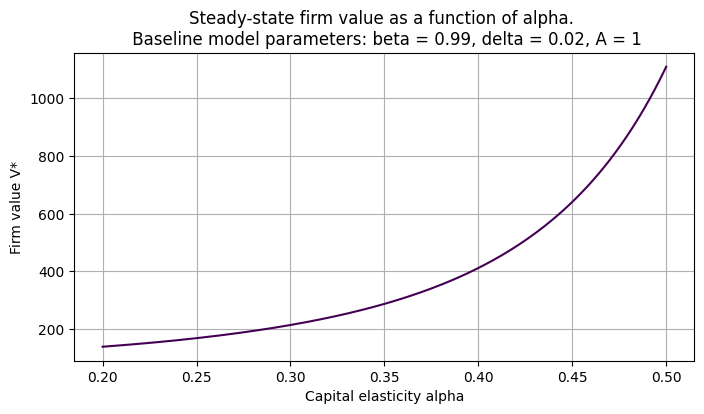

Plotting for parameter: beta


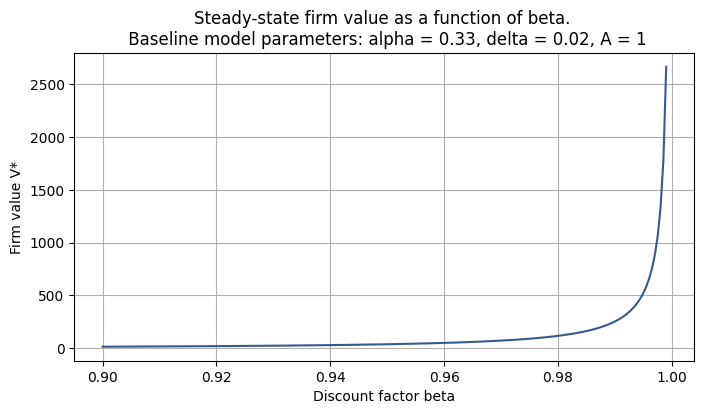

Plotting for parameter: delta


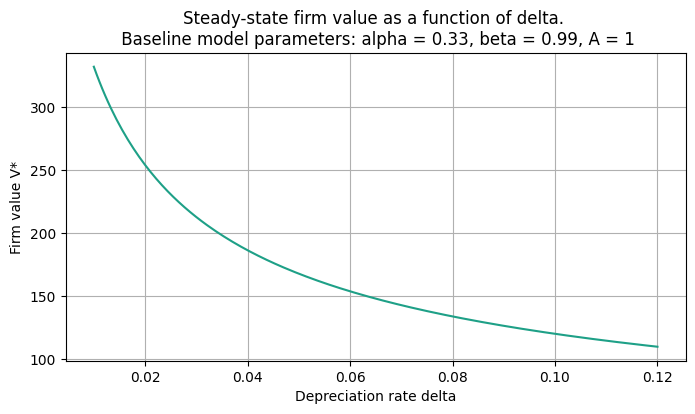

Plotting for parameter: A


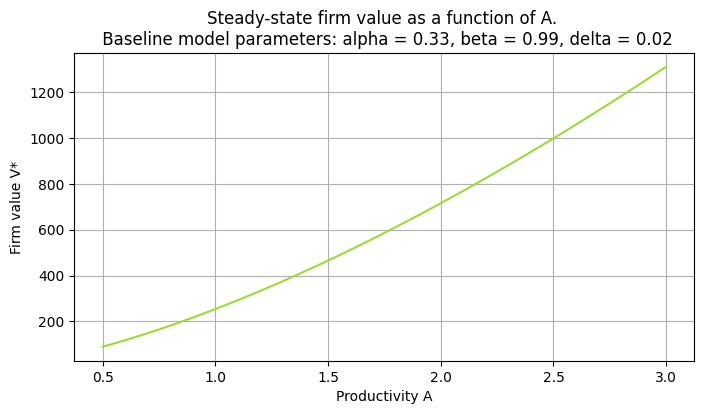

In [2]:
# Parameters for the baseline calibration
alpha = 0.33
beta = 0.99
delta = 0.02
A = 1

# Steady-state formulas
def K_star(A=A, alpha=alpha, beta=beta, delta=delta):
    num = 1 - beta * (1 - delta)
    den = alpha * beta * A
    return (num / den) ** (1 / (alpha - 1))
    
def V_star(A=A, alpha=alpha, beta=beta, delta=delta):
    K = K_star(A, alpha, beta, delta)
    factor = (1 - beta + beta * delta * (1 - alpha)) / (alpha * beta * (1 - beta))
    return K * factor

# Define ranges for all parameters
alpha_vals = np.linspace(0.2, 0.5, 200)
beta_vals = np.linspace(0.90, 0.999, 200)
delta_vals = np.linspace(0.01, 0.12, 200)
A_vals = np.linspace(0.5, 3.0, 200)

# Define dictionaries associating parameter names to their ranges, plot titles, and labels
param_ranges = {
    'alpha': alpha_vals,
    'beta': beta_vals,
    'delta': delta_vals,
    'A': A_vals
} 
param_Vvals = {
    'alpha': V_star(A=A, alpha=alpha_vals, beta=beta, delta=delta),
    'beta': V_star(A=A, alpha=alpha, beta=beta_vals, delta=delta),
    'delta': V_star(A=A, alpha=alpha, beta=beta, delta=delta_vals),
    'A': V_star(A=A_vals, alpha=alpha, beta=beta, delta=delta)
}
param_titles = {
    'alpha': "Steady-state firm value as a function of alpha. \n Baseline model parameters: beta = 0.99, delta = 0.02, A = 1",
    'beta': "Steady-state firm value as a function of beta. \n Baseline model parameters: alpha = 0.33, delta = 0.02, A = 1",
    'delta': "Steady-state firm value as a function of delta. \n Baseline model parameters: alpha = 0.33, beta = 0.99, A = 1",
    'A': "Steady-state firm value as a function of A. \n Baseline model parameters: alpha = 0.33, beta = 0.99, delta = 0.02"
}
param_labels = {
    'alpha': "Capital elasticity alpha",
    'beta': "Discount factor beta",
    'delta': "Depreciation rate delta",
    'A': "Productivity A"
}

for k, param in enumerate(param_ranges.keys()):
    print(f"Plotting for parameter: {param}")
    vals = param_ranges[param]
    V_vals = param_Vvals[param]
    # Plot
    plt.figure(figsize=(8,4))
    plt.plot(vals, V_vals, color=Viridis8[k*2])
    plt.xlabel(param_labels[param])
    plt.ylabel("Firm value V*")
    plt.title(param_titles[param])
    plt.grid(True)
    plt.show()


**Problem 2c**

In [9]:
# Parameters
alpha = 0.33
delta = 0.02
beta  = 0.99
rho   = 0.95          
sigma = 0.01      
Abar  = 1.0

# Deterministic steady state K*
def K_star(alpha, beta, delta, A):
    num = 1 - beta * (1 - delta)
    den = alpha * beta * A
    return (num / den) ** (1 / (alpha - 1))

Kss = K_star(alpha, beta, delta, Abar)
print("Steady-state K* =", Kss)

# Markov chain approximation for log A
def tauchen(N, rho, sigma_eps, m=3):
    """
    AR(1): x_t = rho x_{t-1} + sigma_eps * eps_t, eps~N(0,1)
    Returns grid x (size N) and transition matrix P (N x N).
    """
    std_x = sigma_eps / np.sqrt(1 - rho**2)
    x_max = m * std_x
    x_min = -x_max
    grid = np.linspace(x_min, x_max, N)
    step = (x_max - x_min) / (N - 1)
    P = np.empty((N, N))

    for j in range(N):
        for k in range(N):
            if k == 0:
                z = (grid[0] - rho * grid[j] + step / 2) / sigma_eps
                P[j, k] = norm.cdf(z)
            elif k == N - 1:
                z = (grid[-1] - rho * grid[j] - step / 2) / sigma_eps
                P[j, k] = 1 - norm.cdf(z)
            else:
                z_up = (grid[k] - rho * grid[j] + step / 2) / sigma_eps
                z_down = (grid[k] - rho * grid[j] - step / 2) / sigma_eps
                P[j, k] = norm.cdf(z_up) - norm.cdf(z_down)

    return grid, P

Nz = 7   
logA_grid, Pz = tauchen(Nz, rho, sigma)
A_grid = np.exp(logA_grid)

# Capital grid
Nk = 200
k_min = 0.1 * Kss
k_max = 1.9 * Kss
K_grid = np.linspace(k_min, k_max, Nk)

# Value function iteration
V = np.zeros((Nk, Nz))
policy_K_idx = np.zeros((Nk, Nz), dtype=int)

tol = 1e-6
max_iter = 10000

for it in range(max_iter):
    V_new = np.empty_like(V)

    EV = V @ Pz.T 

    for iz in range(Nz):
        A = A_grid[iz]
        EV_next = EV[:, iz]       

        for ik in range(Nk):
            K = K_grid[ik]
            Kprime = K_grid       
            I = Kprime - (1 - delta) * K
            D = A * (K ** alpha) - I   

            value_vec = D + beta * EV_next
            best_idx = np.argmax(value_vec)

            V_new[ik, iz] = value_vec[best_idx]
            policy_K_idx[ik, iz] = best_idx

    diff = np.max(np.abs(V_new - V))
    V = V_new
    if diff < tol:
        print(f"VFI converged in {it+1} iterations, sup norm diff = {diff:.2e}")
        break
else:
    print("WARNING: VFI did not fully converge")

# Simulation
T = 100_000
rng = np.random.default_rng(1234)

K_idx = np.empty(T, dtype=int)
Z_idx = np.empty(T, dtype=int)
A_series = np.empty(T)
I_series = np.empty(T)
D_series = np.empty(T)
P_ex_series = np.empty(T) 
V_series = np.empty(T)

# initial state: K close to Kss, A close to 1
K_idx[0] = np.argmin(np.abs(K_grid - Kss))
Z_idx[0] = np.argmin(np.abs(A_grid - 1.0))

for t in range(T - 1):
    ik = K_idx[t]
    iz = Z_idx[t]
    K = K_grid[ik]
    A = A_grid[iz]

    # Policy for next-period capital
    ikp = policy_K_idx[ik, iz]
    Kp = K_grid[ikp]

    I = Kp - (1 - delta) * K
    D = A * (K ** alpha) - I

    # Record
    K_idx[t+1] = ikp
    Z_idx[t+1] = rng.choice(Nz, p=Pz[iz, :])

    A_series[t] = A
    I_series[t] = I
    D_series[t] = D
    V_series[t] = V[ik, iz]
    P_ex_series[t] = V[ik, iz] - D 

# Drop last entries that we didn't fill for D, A, etc.
A_series = A_series[:-1]
I_series = I_series[:-1]
D_series = D_series[:-1]
V_series = V_series[:-1]
P_ex_series = P_ex_series[:-1]

# Correlations 
corr_I_A = np.corrcoef(I_series, A_series)[0, 1]
corr_D_A = np.corrcoef(D_series, A_series)[0, 1]
print("corr(I_t, A_t) =", corr_I_A)
print("corr(D_t, A_t) =", corr_D_A)

# Risk-free rate 
R_f = 1.0 / beta
r_f = R_f - 1.0
print(f"Risk-free gross return R_f = {R_f}  (net = {r_f})")

# Stock gross return:
P_ex_next = P_ex_series[1:]
D_next = D_series[1:]
P_ex_curr = P_ex_series[:-1]

R_s = (D_next + P_ex_next) / P_ex_curr
mean_excess = np.mean(R_s) - R_f
print("Mean gross stock return =", np.mean(R_s))
print("Mean excess stock return =", mean_excess)

Steady-state K* = 35.65649190792876
VFI converged in 1455 iterations, sup norm diff = 9.99e-07
corr(I_t, A_t) = 0.20767120388758445
corr(D_t, A_t) = 0.13757726624705985
Risk-free gross return R_f = 1.0101010101010102  (net = 0.010101010101010166)
Mean gross stock return = 1.0101093480489511
Mean excess stock return = 8.337947940972867e-06
